# 07a — EGFR Dimer OpenMM MD Setup

## Pipeline 3 — Molecular Dynamics and Binding-Energy Analysis

This notebook starts the molecular-dynamics stage of PEARL.

### System

- PDB: **3NJP**
- selected interface: **chains B-D**
- force field: **AMBER ff14SB**
- solvent: **TIP3P**
- temperature: **300 K**
- pressure: **1 bar**

### Workflow

```text
3NJP
 ↓
select chains B-D
 ↓
structural repair
 ↓
remove heterogens
 ↓
add hydrogens at physiological pH
 ↓
AMBER ff14SB + TIP3P
 ↓
water + NaCl
 ↓
energy minimisation
 ↓
short NVT equilibration
 ↓
short NPT equilibration
 ↓
production-ready state
```

This notebook **does not run the long production MD**. That will be the purpose of the next Pipeline 3 stage.

### Docking versus MD

Docking/refinement explores plausible receptor-peptide poses and conformations. Molecular dynamics instead propagates a prepared atomic system through time according to a physical force field. This is therefore a new validation layer, not a repetition of the FlexPepDock calculations already performed in Pipeline 2.


In [1]:
# ATTENZIONE SELEZIONARE DAL KERNEL PYTHON (PEARL MD)
import sys
import openmm
from pdbfixer import PDBFixer

print(sys.executable)
print(openmm.__version__)
print("PDBFixer OK")

/Users/robertobruzzese/miniforge3/envs/pearl-md/bin/python
8.5.2
PDBFixer OK


## 1. Installation

Recommended:

```bash
conda create -n pearl-md python=3.11
conda activate pearl-md
conda install -c conda-forge openmm pdbfixer numpy pandas matplotlib
```

The notebook detects the OpenMM compute platforms available on the machine and selects CUDA, OpenCL or CPU in that order when available.


In [23]:
from pathlib import Path
import json
import platform as py_platform
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm
from openmm import Platform, LangevinMiddleIntegrator, MonteCarloBarostat, XmlSerializer
from openmm.app import (
    PDBFile, Modeller, ForceField, Simulation, PME, HBonds, StateDataReporter
)
from openmm.unit import (
    kelvin, bar, nanometer, picosecond, molar, kilojoule_per_mole
)
from pdbfixer import PDBFixer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

print("Python:", sys.version.split()[0])
print("OpenMM:", openmm.__version__)
print("System:", py_platform.platform())


Python: 3.11.15
OpenMM: 8.5.2
System: macOS-15.7.5-arm64-arm-64bit


## 2. Configuration

In [24]:
PDB_ID = "3NJP"
KEEP_CHAINS = ("B", "D")

PH = 7.4
ADD_MISSING_RESIDUES = False
REPLACE_NONSTANDARD_RESIDUES = True
REMOVE_HETEROGENS = True

PROTEIN_FORCEFIELD = "amber14/protein.ff14SB.xml"
WATER_FORCEFIELD = "amber14/tip3p.xml"

WATER_PADDING_NM = 1.0
IONIC_STRENGTH_M = 0.15
POSITIVE_ION = "Na+"
NEGATIVE_ION = "Cl-"

TEMPERATURE_K = 300.0
PRESSURE_BAR = 1.0
FRICTION_PER_PS = 1.0
TIMESTEP_PS = 0.002
NONBONDED_CUTOFF_NM = 1.0
RANDOM_SEED = 20260808

# Start with True. Once the complete notebook works, set False.
#FAST_TEST_MODE = True
FAST_TEST_MODE = False
if FAST_TEST_MODE:
    NVT_PS = 10.0
    NPT_PS = 10.0
else:
    NVT_PS = 100.0
    NPT_PS = 100.0

RUN_MINIMIZATION = True
RUN_NVT = True
RUN_NPT = True
MINIMIZATION_MAX_ITERATIONS = 5000
REPORT_INTERVAL_STEPS = 1000 if FAST_TEST_MODE else 5000

OUTPUT_ROOT = Path("outputs")
RESULT_DIR = OUTPUT_ROOT / "pipeline_3_md_07a_egfr_dimer_setup"
STRUCTURE_DIR = RESULT_DIR / "structures"
STATE_DIR = RESULT_DIR / "states"
LOG_DIR = RESULT_DIR / "logs"
REPORT_DIR = RESULT_DIR / "reports"

for d in [RESULT_DIR, STRUCTURE_DIR, STATE_DIR, LOG_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_BD_PDB = STRUCTURE_DIR / "3NJP_BD_raw.pdb"
PREPARED_PDB = STRUCTURE_DIR / "3NJP_BD_prepared_no_solvent.pdb"
SOLVATED_PDB = STRUCTURE_DIR / "3NJP_BD_solvated.pdb"
MINIMIZED_PDB = STRUCTURE_DIR / "3NJP_BD_minimized.pdb"
EQUILIBRATED_PDB = STRUCTURE_DIR / "3NJP_BD_equilibrated.pdb"

SYSTEM_XML = STATE_DIR / "3NJP_BD_openmm_system.xml"
FINAL_STATE_XML = STATE_DIR / "3NJP_BD_equilibrated_state.xml"
CHECKPOINT = STATE_DIR / "3NJP_BD_equilibrated.chk"

NVT_LOG = LOG_DIR / "nvt_equilibration.csv"
NPT_LOG = LOG_DIR / "npt_equilibration.csv"

CONFIG_JSON = RESULT_DIR / "07a_md_setup_config.json"
QC_CSV = RESULT_DIR / "07a_system_qc.csv"
REPORT_MD = REPORT_DIR / "07a_md_setup_report.md"

print("Output:", RESULT_DIR.resolve())
print("FAST_TEST_MODE:", FAST_TEST_MODE)
print("NVT:", NVT_PS, "ps")
print("NPT:", NPT_PS, "ps")


Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup
FAST_TEST_MODE: False
NVT: 100.0 ps
NPT: 100.0 ps


## 3. Available OpenMM compute platforms

In [25]:
available_platforms = [
    Platform.getPlatform(i).getName()
    for i in range(Platform.getNumPlatforms())
]

print("Available:", available_platforms)

preferred = ["CUDA", "OpenCL", "CPU", "Reference"]
selected_platform_name = next(
    (name for name in preferred if name in available_platforms),
    available_platforms[-1],
)

OPENMM_PLATFORM = Platform.getPlatformByName(selected_platform_name)
print("Selected:", selected_platform_name)


Available: ['Reference', 'CPU', 'OpenCL']
Selected: OpenCL


## 4. Download 3NJP and retain chains B-D

The notebook downloads 3NJP through PDBFixer, checks the available chains, and keeps only chains B and D.


In [26]:
fixer = PDBFixer(pdbid=PDB_ID)

original_chains = list(fixer.topology.chains())

rows = []
for i, chain in enumerate(original_chains):
    rows.append({
        "index": i,
        "chain": chain.id,
        "n_residues": sum(1 for _ in chain.residues()),
        "n_atoms": sum(1 for _ in chain.atoms()),
    })

chain_table = pd.DataFrame(rows)
display(chain_table)

present_ids = set(chain_table["chain"].astype(str))
missing_requested = set(KEEP_CHAINS) - present_ids

if missing_requested:
    raise ValueError(
        "Requested chains are missing: " + ", ".join(sorted(missing_requested))
    )

remove_indices = [
    i for i, chain in enumerate(original_chains)
    if chain.id not in KEEP_CHAINS
]

fixer.removeChains(remove_indices)

remaining = list(fixer.topology.chains())
print("Remaining chains:", [c.id for c in remaining])

with RAW_BD_PDB.open("w") as handle:
    PDBFile.writeFile(
        fixer.topology, fixer.positions, handle, keepIds=True
    )

print("Saved:", RAW_BD_PDB.resolve())


,index,chain,n_residues,n_atoms
0,0,A,614,4725
1,1,B,614,4725
2,2,C,47,386
3,3,D,47,386
4,4,A,8,112
5,5,B,7,140
6,6,D,2,56
7,7,A,13,13
8,8,B,5,5
9,9,C,5,5


Remaining chains: ['B', 'D', 'B', 'D', 'B', 'D']
Saved: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup/structures/3NJP_BD_raw.pdb


## 5. Inspect missing residues

In [27]:
fixer.findMissingResidues()

chains_now = list(fixer.topology.chains())
missing_rows = []

for (chain_index, insertion_index), residue_names in fixer.missingResidues.items():
    chain_id = (
        chains_now[chain_index].id
        if chain_index < len(chains_now)
        else f"index_{chain_index}"
    )
    missing_rows.append({
        "chain": chain_id,
        "chain_index": chain_index,
        "insertion_index": insertion_index,
        "n_missing": len(residue_names),
        "residue_names": "-".join(residue_names),
    })

missing_residues_df = pd.DataFrame(missing_rows)

if missing_residues_df.empty:
    print("No missing residue blocks reported.")
else:
    display(missing_residues_df)

if not ADD_MISSING_RESIDUES:
    fixer.missingResidues = {}
    print("Missing residues will NOT be modelled automatically.")
else:
    print("PDBFixer will attempt to model the reported missing residues.")


No missing residue blocks reported.
Missing residues will NOT be modelled automatically.


### Missing-residue policy

Unresolved loops are not rebuilt silently by default because doing so can introduce a new structural hypothesis at the interface. Missing heavy atoms in resolved residues are repaired below. If a biologically important internal gap is detected, it should be reviewed before enabling automatic residue modelling.


## 6. Non-standard residues and heterogens

In [28]:
fixer.findNonstandardResidues()

nonstandard_rows = [
    {
        "chain": residue.chain.id,
        "residue_id": residue.id,
        "residue_name": residue.name,
        "suggested_replacement": replacement,
    }
    for residue, replacement in fixer.nonstandardResidues
]

nonstandard_df = pd.DataFrame(nonstandard_rows)

if nonstandard_df.empty:
    print("No non-standard residues detected.")
else:
    display(nonstandard_df)

if REPLACE_NONSTANDARD_RESIDUES and fixer.nonstandardResidues:
    fixer.replaceNonstandardResidues()
    print("Non-standard residues replaced.")

if REMOVE_HETEROGENS:
    fixer.removeHeterogens(False)
    print("All heterogens, including crystallographic waters, removed.")


,chain,residue_id,residue_name,suggested_replacement
0,B,32,ASN,ASN
1,B,151,ASN,ASN
2,B,328,ASN,ASN
3,B,504,ASN,ASN


Non-standard residues replaced.
All heterogens, including crystallographic waters, removed.


## 7. Repair missing heavy atoms

In [29]:
fixer.findMissingAtoms()

missing_atom_rows = []

for residue, atoms in fixer.missingAtoms.items():
    missing_atom_rows.append({
        "chain": residue.chain.id,
        "residue_id": residue.id,
        "residue_name": residue.name,
        "kind": "heavy_atoms",
        "atoms": ",".join(atom.name for atom in atoms),
        "n_atoms": len(atoms),
    })

for residue, atoms in fixer.missingTerminals.items():
    missing_atom_rows.append({
        "chain": residue.chain.id,
        "residue_id": residue.id,
        "residue_name": residue.name,
        "kind": "terminal_atoms",
        "atoms": ",".join(atom.name for atom in atoms),
        "n_atoms": len(atoms),
    })

missing_atoms_df = pd.DataFrame(missing_atom_rows)

if missing_atoms_df.empty:
    print("No missing heavy/terminal atoms detected.")
else:
    display(missing_atoms_df.head(50))

fixer.addMissingAtoms()
print("Heavy/terminal atom repair completed.")


No missing heavy/terminal atoms detected.
Heavy/terminal atom repair completed.


## 8. Force field and protonation

In [30]:
forcefield = ForceField(
    PROTEIN_FORCEFIELD,
    WATER_FORCEFIELD,
)

modeller = Modeller(fixer.topology, fixer.positions)

atoms_before_h = modeller.topology.getNumAtoms()

modeller.addHydrogens(
    forcefield,
    pH=PH,
)

atoms_after_h = modeller.topology.getNumAtoms()

print("Atoms before H:", atoms_before_h)
print("Atoms after H :", atoms_after_h)
print("Added        :", atoms_after_h - atoms_before_h)

with PREPARED_PDB.open("w") as handle:
    PDBFile.writeFile(
        modeller.topology,
        modeller.positions,
        handle,
        keepIds=True,
    )

print("Saved:", PREPARED_PDB.resolve())


Atoms before H: 5111
Atoms after H : 10019
Added        : 4908
Saved: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup/structures/3NJP_BD_prepared_no_solvent.pdb


## 9. Pre-solvation topology QC

In [31]:
def topology_summary(topology):
    rows = []
    for chain in topology.chains():
        residues = list(chain.residues())
        atoms = [a for r in residues for a in r.atoms()]
        rows.append({
            "chain": chain.id,
            "n_residues": len(residues),
            "n_atoms": len(atoms),
            "first_residue": f"{residues[0].name}{residues[0].id}" if residues else None,
            "last_residue": f"{residues[-1].name}{residues[-1].id}" if residues else None,
        })
    return pd.DataFrame(rows)

pre_solvent_summary = topology_summary(modeller.topology)
display(pre_solvent_summary)

protein_chain_ids = set(pre_solvent_summary["chain"].astype(str))
if not set(KEEP_CHAINS).issubset(protein_chain_ids):
    raise RuntimeError("Chain IDs B and D were not preserved.")

print("Chain check: PASS")


,chain,n_residues,n_atoms,first_residue,last_residue
0,B,614,9286,LEU1,THR614
1,D,47,733,GLU5,GLU51


Chain check: PASS


## 10. Solvate and add ions

In [32]:
atoms_before_solvent = modeller.topology.getNumAtoms()
residues_before_solvent = modeller.topology.getNumResidues()

modeller.addSolvent(
    forcefield,
    model="tip3p",
    padding=WATER_PADDING_NM * nanometer,
    positiveIon=POSITIVE_ION,
    negativeIon=NEGATIVE_ION,
    ionicStrength=IONIC_STRENGTH_M * molar,
    neutralize=True,
)

atoms_after_solvent = modeller.topology.getNumAtoms()
residues_after_solvent = modeller.topology.getNumResidues()

print("Atoms before solvent :", atoms_before_solvent)
print("Atoms after solvent  :", atoms_after_solvent)
print("Residues before      :", residues_before_solvent)
print("Residues after       :", residues_after_solvent)

with SOLVATED_PDB.open("w") as handle:
    PDBFile.writeFile(
        modeller.topology,
        modeller.positions,
        handle,
        keepIds=True,
    )

print("Saved:", SOLVATED_PDB.resolve())


Atoms before solvent : 10019
Atoms after solvent  : 310418
Residues before      : 661
Residues after       : 101162
Saved: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup/structures/3NJP_BD_solvated.pdb


## 11. Count solvent and ions

In [33]:
residue_counts = {}

for residue in modeller.topology.residues():
    residue_counts[residue.name] = residue_counts.get(residue.name, 0) + 1

water_names = {"HOH", "WAT"}
ion_names = {"NA", "CL", "Na+", "Cl-"}

n_water = sum(
    count
    for name, count in residue_counts.items()
    if name in water_names
)

ion_counts = {
    name: count
    for name, count in residue_counts.items()
    if name in ion_names
}

print("Water molecules:", n_water)
print("Ion counts:", ion_counts)

display(
    pd.DataFrame(
        sorted(residue_counts.items(), key=lambda x: x[1], reverse=True)[:15],
        columns=["residue_name", "count"],
    )
)


Water molecules: 99949
Ion counts: {'NA': 280, 'CL': 272}


,residue_name,count
0,HOH,99949
1,NA,280
2,CL,272
3,CYS,56
4,LEU,54
5,GLY,54
6,GLU,44
7,ASN,44
8,SER,40
9,LYS,38


## 12. Create periodic OpenMM system

In [34]:
system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=PME,
    nonbondedCutoff=NONBONDED_CUTOFF_NM * nanometer,
    constraints=HBonds,
    rigidWater=True,
    ewaldErrorTolerance=5e-4,
)

print("Particles:", system.getNumParticles())
print("Forces:", system.getNumForces())

for i in range(system.getNumForces()):
    print(i, system.getForce(i).__class__.__name__)


Particles: 310418
Forces: 5
0 HarmonicBondForce
1 PeriodicTorsionForce
2 NonbondedForce
3 CMMotionRemover
4 HarmonicAngleForce


## 13. Energy minimisation

In [35]:
integrator_nvt = LangevinMiddleIntegrator(
    TEMPERATURE_K * kelvin,
    FRICTION_PER_PS / picosecond,
    TIMESTEP_PS * picosecond,
)
integrator_nvt.setRandomNumberSeed(RANDOM_SEED)

simulation = Simulation(
    modeller.topology,
    system,
    integrator_nvt,
    OPENMM_PLATFORM,
)
simulation.context.setPositions(modeller.positions)

initial_state = simulation.context.getState(getEnergy=True)
initial_potential = initial_state.getPotentialEnergy().value_in_unit(kilojoule_per_mole)

print(f"Initial potential energy: {initial_potential:.3f} kJ/mol")

if RUN_MINIMIZATION:
    t0 = time.time()
    simulation.minimizeEnergy(maxIterations=MINIMIZATION_MAX_ITERATIONS)
    minimization_elapsed = time.time() - t0

    minimized_state = simulation.context.getState(
        getEnergy=True,
        getPositions=True,
    )
    minimized_potential = (
        minimized_state.getPotentialEnergy()
        .value_in_unit(kilojoule_per_mole)
    )

    print(f"Minimized potential energy: {minimized_potential:.3f} kJ/mol")
    print(f"Energy change: {minimized_potential - initial_potential:.3f} kJ/mol")
    print(f"Elapsed: {minimization_elapsed:.1f} s")

    with MINIMIZED_PDB.open("w") as handle:
        PDBFile.writeFile(
            simulation.topology,
            minimized_state.getPositions(),
            handle,
            keepIds=True,
        )
else:
    minimized_state = simulation.context.getState(
        getEnergy=True,
        getPositions=True,
    )
    minimized_potential = initial_potential
    minimization_elapsed = 0.0
    print("Minimization skipped.")


Initial potential energy: -3431165.452 kJ/mol
Minimized potential energy: -5323796.327 kJ/mol
Energy change: -1892630.875 kJ/mol
Elapsed: 48.7 s


## 14. NVT equilibration

With `FAST_TEST_MODE=True`, only a short smoke-test equilibration is run. After this completes successfully, switch to `False` for a longer equilibration.


In [36]:
nvt_steps = int(NVT_PS / TIMESTEP_PS)

print("NVT duration:", NVT_PS, "ps")
print("NVT steps:", nvt_steps)

if RUN_NVT:
    simulation.context.setVelocitiesToTemperature(
        TEMPERATURE_K * kelvin,
        RANDOM_SEED,
    )

    simulation.reporters.append(
        StateDataReporter(
            str(NVT_LOG),
            REPORT_INTERVAL_STEPS,
            step=True,
            time=True,
            potentialEnergy=True,
            kineticEnergy=True,
            totalEnergy=True,
            temperature=True,
            speed=True,
            separator=",",
        )
    )

    t0 = time.time()
    simulation.step(nvt_steps)
    nvt_elapsed = time.time() - t0

    nvt_state = simulation.context.getState(
        getPositions=True,
        getVelocities=True,
        getEnergy=True,
    )

    print(f"NVT completed in {nvt_elapsed:.1f} s")
else:
    nvt_state = simulation.context.getState(
        getPositions=True,
        getVelocities=True,
        getEnergy=True,
    )
    nvt_elapsed = 0.0
    print("NVT skipped.")


NVT duration: 100.0 ps
NVT steps: 50000
NVT completed in 374.9 s


## 15. NPT equilibration

In [37]:
barostat = MonteCarloBarostat(
    PRESSURE_BAR * bar,
    TEMPERATURE_K * kelvin,
    25,
)

system.addForce(barostat)

integrator_npt = LangevinMiddleIntegrator(
    TEMPERATURE_K * kelvin,
    FRICTION_PER_PS / picosecond,
    TIMESTEP_PS * picosecond,
)
integrator_npt.setRandomNumberSeed(RANDOM_SEED + 1)

simulation_npt = Simulation(
    modeller.topology,
    system,
    integrator_npt,
    OPENMM_PLATFORM,
)

simulation_npt.context.setState(nvt_state)

npt_steps = int(NPT_PS / TIMESTEP_PS)

print("NPT duration:", NPT_PS, "ps")
print("NPT steps:", npt_steps)

if RUN_NPT:
    simulation_npt.reporters.append(
        StateDataReporter(
            str(NPT_LOG),
            REPORT_INTERVAL_STEPS,
            step=True,
            time=True,
            potentialEnergy=True,
            kineticEnergy=True,
            totalEnergy=True,
            temperature=True,
            volume=True,
            density=True,
            speed=True,
            separator=",",
        )
    )

    t0 = time.time()
    simulation_npt.step(npt_steps)
    npt_elapsed = time.time() - t0

    final_state = simulation_npt.context.getState(
        getPositions=True,
        getVelocities=True,
        getEnergy=True,
        enforcePeriodicBox=True,
    )

    print(f"NPT completed in {npt_elapsed:.1f} s")
else:
    final_state = simulation_npt.context.getState(
        getPositions=True,
        getVelocities=True,
        getEnergy=True,
        enforcePeriodicBox=True,
    )
    npt_elapsed = 0.0
    print("NPT skipped.")


NPT duration: 100.0 ps
NPT steps: 50000
NPT completed in 416.5 s


## 16. Save production-ready system and state

In [38]:
with EQUILIBRATED_PDB.open("w") as handle:
    PDBFile.writeFile(
        simulation_npt.topology,
        final_state.getPositions(),
        handle,
        keepIds=True,
    )

SYSTEM_XML.write_text(
    XmlSerializer.serialize(system),
    encoding="utf-8",
)

FINAL_STATE_XML.write_text(
    XmlSerializer.serialize(final_state),
    encoding="utf-8",
)

simulation_npt.saveCheckpoint(str(CHECKPOINT))

print("Equilibrated PDB:", EQUILIBRATED_PDB.resolve())
print("System XML      :", SYSTEM_XML.resolve())
print("State XML       :", FINAL_STATE_XML.resolve())
print("Checkpoint      :", CHECKPOINT.resolve())


Equilibrated PDB: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup/structures/3NJP_BD_equilibrated.pdb
System XML      : /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup/states/3NJP_BD_openmm_system.xml
State XML       : /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup/states/3NJP_BD_equilibrated_state.xml
Checkpoint      : /Users/robertobruzzese/Desktop/venv/outputs/pipeline_3_md_07a_egfr_dimer_setup/states/3NJP_BD_equilibrated.chk


## 17. Equilibration diagnostics

In [39]:
def read_state_log(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

nvt_log_df = read_state_log(NVT_LOG)
npt_log_df = read_state_log(NPT_LOG)

print("NVT rows:", len(nvt_log_df))
print("NPT rows:", len(npt_log_df))

if not nvt_log_df.empty:
    display(nvt_log_df.tail())

if not npt_log_df.empty:
    display(npt_log_df.tail())


NVT rows: 10
NPT rows: 10


,"#""Step""",Time (ps),Potential Energy (kJ/mole),Kinetic Energy (kJ/mole),Total Energy (kJ/mole),Temperature (K),Speed (ns/day)
5,30000,60.0,-4.271022e+06,783448.2500,-3.487574e+06,300.806920,22.6
6,35000,70.0,-4.272111e+06,782418.2500,-3.489693e+06,300.411449,22.3
7,40000,80.0,-4.273506e+06,781991.0625,-3.491515e+06,300.247429,22.3
8,45000,90.0,-4.273974e+06,780661.7500,-3.493312e+06,299.737036,22.3
9,50000,100.0,-4.275656e+06,783152.9375,-3.492504e+06,300.693534,22.4


,"#""Step""",Time (ps),Potential Energy (kJ/mole),Kinetic Energy (kJ/mole),Total Energy (kJ/mole),Temperature (K),Box Volume (nm^3),Density (g/mL),Speed (ns/day)
5,80000,160.0,-4.292843e+06,781176.0625,-3.511667e+06,299.934508,3127.942256,1.003395,21.3
6,85000,170.0,-4.293825e+06,782734.1250,-3.511091e+06,300.532730,3128.259567,1.003293,21.1
7,90000,180.0,-4.293436e+06,782301.5000,-3.511135e+06,300.366622,3137.219063,1.000427,20.9
8,95000,190.0,-4.294557e+06,782405.2500,-3.512152e+06,300.406458,3134.928899,1.001158,20.8
9,100000,200.0,-4.294583e+06,784639.1250,-3.509944e+06,301.264159,3127.702455,1.003471,20.8


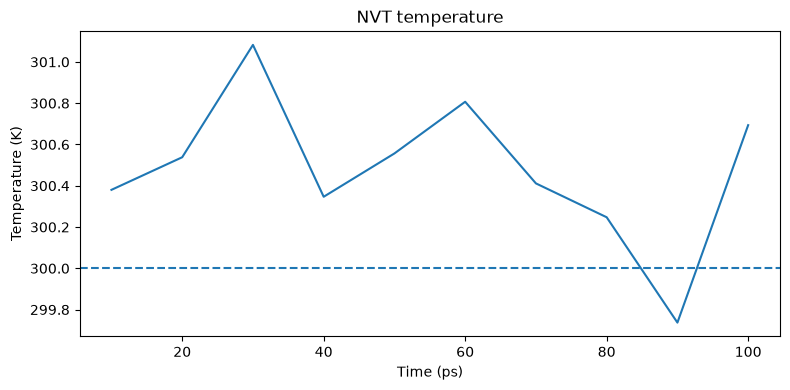

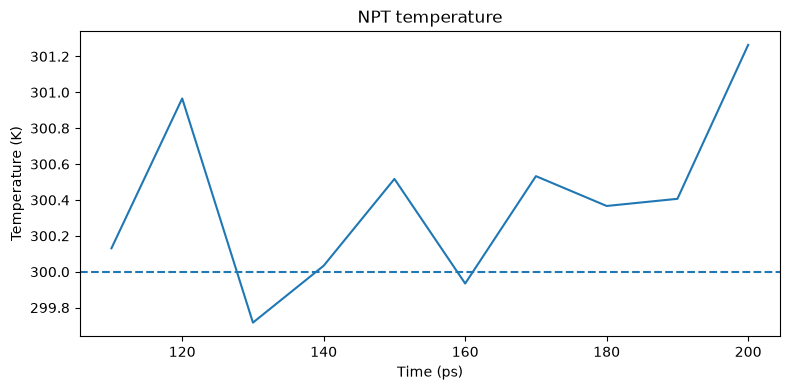

In [40]:
def find_column(df, keyword):
    keyword = keyword.lower()
    return next(
        (c for c in df.columns if keyword in str(c).lower()),
        None,
    )

if not nvt_log_df.empty:
    tcol = find_column(nvt_log_df, "time")
    ycol = find_column(nvt_log_df, "temperature")
    if tcol and ycol:
        plt.figure(figsize=(8, 4))
        plt.plot(nvt_log_df[tcol], nvt_log_df[ycol])
        plt.axhline(TEMPERATURE_K, linestyle="--")
        plt.xlabel(tcol)
        plt.ylabel(ycol)
        plt.title("NVT temperature")
        plt.tight_layout()
        plt.savefig(REPORT_DIR / "nvt_temperature.png", dpi=250, bbox_inches="tight")
        plt.show()

if not npt_log_df.empty:
    tcol = find_column(npt_log_df, "time")
    ycol = find_column(npt_log_df, "temperature")
    if tcol and ycol:
        plt.figure(figsize=(8, 4))
        plt.plot(npt_log_df[tcol], npt_log_df[ycol])
        plt.axhline(TEMPERATURE_K, linestyle="--")
        plt.xlabel(tcol)
        plt.ylabel(ycol)
        plt.title("NPT temperature")
        plt.tight_layout()
        plt.savefig(REPORT_DIR / "npt_temperature.png", dpi=250, bbox_inches="tight")
        plt.show()


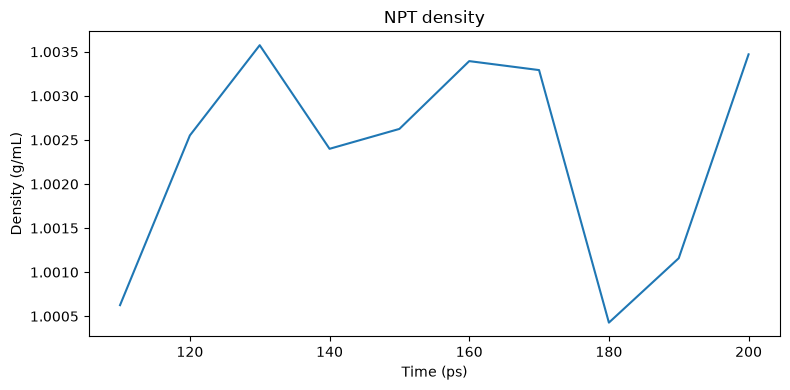

In [41]:
if not npt_log_df.empty:
    tcol = find_column(npt_log_df, "time")
    dcol = find_column(npt_log_df, "density")
    if tcol and dcol:
        plt.figure(figsize=(8, 4))
        plt.plot(npt_log_df[tcol], npt_log_df[dcol])
        plt.xlabel(tcol)
        plt.ylabel(dcol)
        plt.title("NPT density")
        plt.tight_layout()
        plt.savefig(REPORT_DIR / "npt_density.png", dpi=250, bbox_inches="tight")
        plt.show()


## 18. Final QC

In [42]:
final_topology = simulation_npt.topology
n_atoms_final = final_topology.getNumAtoms()
n_residues_final = final_topology.getNumResidues()

final_chain_summary = topology_summary(final_topology)

protein_summary = final_chain_summary[
    final_chain_summary["chain"].astype(str).isin(KEEP_CHAINS)
].copy()

qc_df = pd.DataFrame([
    {
        "check": "requested_chains_present",
        "value": set(KEEP_CHAINS).issubset(
            set(protein_summary["chain"].astype(str))
        ),
    },
    {
        "check": "system_particles_match_topology_atoms",
        "value": system.getNumParticles() == n_atoms_final,
    },
    {
        "check": "finite_initial_energy",
        "value": np.isfinite(initial_potential),
    },
    {
        "check": "finite_minimized_energy",
        "value": np.isfinite(minimized_potential),
    },
    {
        "check": "final_state_saved",
        "value": FINAL_STATE_XML.exists(),
    },
    {
        "check": "checkpoint_saved",
        "value": CHECKPOINT.exists(),
    },
])

display(qc_df)

all_qc_passed = bool(qc_df["value"].all())

print("ALL QC PASSED:", all_qc_passed)
print("Final atoms:", n_atoms_final)
print("Final residues:", n_residues_final)
print("Water molecules:", n_water)
print("Platform:", selected_platform_name)


,check,value
0,requested_chains_present,True
1,system_particles_match_topology_atoms,True
2,finite_initial_energy,True
3,finite_minimized_energy,True
4,final_state_saved,True
5,checkpoint_saved,True


ALL QC PASSED: True
Final atoms: 310418
Final residues: 101162
Water molecules: 99949
Platform: OpenCL


## 19. Save configuration and automatic report

In [43]:
config = {
    "pdb_id": PDB_ID,
    "keep_chains": list(KEEP_CHAINS),
    "pH": PH,
    "add_missing_residues": ADD_MISSING_RESIDUES,
    "replace_nonstandard_residues": REPLACE_NONSTANDARD_RESIDUES,
    "remove_heterogens": REMOVE_HETEROGENS,
    "protein_forcefield": PROTEIN_FORCEFIELD,
    "water_forcefield": WATER_FORCEFIELD,
    "water_padding_nm": WATER_PADDING_NM,
    "ionic_strength_M": IONIC_STRENGTH_M,
    "temperature_K": TEMPERATURE_K,
    "pressure_bar": PRESSURE_BAR,
    "timestep_ps": TIMESTEP_PS,
    "fast_test_mode": FAST_TEST_MODE,
    "nvt_ps": NVT_PS,
    "npt_ps": NPT_PS,
    "platform": selected_platform_name,
    "random_seed": RANDOM_SEED,
    "n_atoms_final": int(n_atoms_final),
    "n_residues_final": int(n_residues_final),
    "n_water": int(n_water),
    "ion_counts": {str(k): int(v) for k, v in ion_counts.items()},
    "initial_potential_kJ_mol": float(initial_potential),
    "minimized_potential_kJ_mol": float(minimized_potential),
    "all_qc_passed": all_qc_passed,
}

CONFIG_JSON.write_text(
    json.dumps(config, indent=2),
    encoding="utf-8",
)

qc_df.to_csv(QC_CSV, index=False)

missing_residues_text = "none" if missing_residues_df.empty else str(len(missing_residues_df))
nonstandard_text = "none" if nonstandard_df.empty else str(len(nonstandard_df))

report = f"""# 07a - EGFR Dimer OpenMM MD Setup

## System
- PDB: {PDB_ID}
- Chains: {KEEP_CHAINS[0]}-{KEEP_CHAINS[1]}
- Force field: {PROTEIN_FORCEFIELD}
- Water: {WATER_FORCEFIELD}
- pH: {PH}
- NaCl target: {IONIC_STRENGTH_M} M
- Water padding: {WATER_PADDING_NM} nm

## Structural preparation
- Missing-residue blocks reported: {missing_residues_text}
- Automatic missing-residue modelling: {ADD_MISSING_RESIDUES}
- Non-standard residues reported: {nonstandard_text}
- Heterogens removed: {REMOVE_HETEROGENS}

## Simulation setup
- Temperature: {TEMPERATURE_K} K
- Pressure: {PRESSURE_BAR} bar
- Timestep: {TIMESTEP_PS * 1000:.1f} fs
- NVT: {NVT_PS} ps
- NPT: {NPT_PS} ps
- Fast test mode: {FAST_TEST_MODE}
- OpenMM platform: {selected_platform_name}

## Final system
- Atoms: {n_atoms_final}
- Residues: {n_residues_final}
- Waters: {n_water}
- Ions: {ion_counts}
- Initial potential energy: {initial_potential:.3f} kJ/mol
- Minimized potential energy: {minimized_potential:.3f} kJ/mol
- All QC passed: {all_qc_passed}

## Main outputs
- {EQUILIBRATED_PDB}
- {SYSTEM_XML}
- {FINAL_STATE_XML}
- {CHECKPOINT}

## Interpretation
This notebook prepares and briefly equilibrates the B-D EGFR dimer system.
It does not constitute the final production molecular-dynamics simulation.
The next Pipeline 3 stage should run a longer NPT trajectory and evaluate
interface-contact persistence, RMSD/RMSF and related dynamic descriptors.
"""

REPORT_MD.write_text(report, encoding="utf-8")

print(report)
print("Config:", CONFIG_JSON.resolve())
print("QC:", QC_CSV.resolve())
print("Report:", REPORT_MD.resolve())


# 07a - EGFR Dimer OpenMM MD Setup

## System
- PDB: 3NJP
- Chains: B-D
- Force field: amber14/protein.ff14SB.xml
- Water: amber14/tip3p.xml
- pH: 7.4
- NaCl target: 0.15 M
- Water padding: 1.0 nm

## Structural preparation
- Missing-residue blocks reported: none
- Automatic missing-residue modelling: False
- Non-standard residues reported: 4
- Heterogens removed: True

## Simulation setup
- Temperature: 300.0 K
- Pressure: 1.0 bar
- Timestep: 2.0 fs
- NVT: 100.0 ps
- NPT: 100.0 ps
- Fast test mode: False
- OpenMM platform: OpenCL

## Final system
- Atoms: 310418
- Residues: 101162
- Waters: 99949
- Ions: {'NA': 280, 'CL': 272}
- Initial potential energy: -3431165.452 kJ/mol
- Minimized potential energy: -5323796.327 kJ/mol
- All QC passed: True

## Main outputs
- outputs/pipeline_3_md_07a_egfr_dimer_setup/structures/3NJP_BD_equilibrated.pdb
- outputs/pipeline_3_md_07a_egfr_dimer_setup/states/3NJP_BD_openmm_system.xml
- outputs/pipeline_3_md_07a_egfr_dimer_setup/states/3NJP_BD_equilibr

# 20. Next step

If `ALL QC PASSED` is `True`, the next notebook can use:

```text
outputs/pipeline_3_md_07a_egfr_dimer_setup/
├── structures/
│   └── 3NJP_BD_equilibrated.pdb
└── states/
    ├── 3NJP_BD_openmm_system.xml
    ├── 3NJP_BD_equilibrated_state.xml
    └── 3NJP_BD_equilibrated.chk
```

for the production stage:

```text
07b_EGFR_Dimer_MD_Contact_Persistence.ipynb
```

That stage should run the actual NPT trajectory and calculate:

- backbone/protein RMSD;
- residue RMSF;
- B-D interface-contact persistence;
- persistent hotspot contacts;
- comparison with the original static interface.

Do not start a long production run until this notebook finishes cleanly.
